This notebook is an attempt to summarise the data analysis work done on the GEN 1 and 2 HFGW Data (not MAGE)

In [1]:
import h5py
import datetime
import timeit
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy import linalg
from scipy import fft
from scipy import stats

In [3]:
#run name and experiment name

exp_name = '4K GEN2HG'

run_name = 'run4'

#reference frequencies of each lockin amplifier for the specified run
f_lockin1 = 4.993017E6 
f_lockin2 = 5.505658500E+6 - 2.8

#filepath leading to the experiment Data
filepath = r"C:\Users\21958742\DarkMatterCentre Dropbox\William Campbell\PhD\High Frequency GW\Data Analysis"

#raw data
f=h5py.File(filepath + '/' + exp_name + '/' + run_name + '/' + run_name +  '.hdf5','r')

#limit data size for test purposes
test_size = 1000000

# 4 data streams
channel_1X=f['1X/Data'][:test_size]
channel_1Y=f['1Y/Data'][:test_size]
channel_2X=f['2X/Data'][:test_size]
channel_2Y=f['2Y/Data'][:test_size]

# Impulse event search

First and most simple analysis was an event search for 5$\sigma$ outliers in the magnitude signal $R^2[n] = X^2[n] + Y^2[n]$, $n = {0,...,N}$. Where $N$ is the total length of the data set, X and Y are the two quadrature signals output by the lock-in

In [46]:
#data was sampled at 100 Hz
fs_rate=100

N = len(channel_1X)

#data set is time-stamped for start time, can determine end time 
time_ini_str = f_raw.attrs['starttime'][12:]
time_ini = datetime.datetime.strptime(time_ini_str,"%Y-%m-%d %H:%M:%S.%f") - datetime.timedelta(hours=8)
time_fin = time_ini + datetime.timedelta(seconds=N/fs_rate)
print('Start: '+str(time_ini))
print('End: '+str(time_fin))


Start: 2019-11-26 06:43:20.421359
End: 2019-11-26 09:30:00.421359


Determine mean and standard deviation of each channel

In [37]:
mean_1X = np.mean(channel_1X)
mean_1Y = np.mean(channel_1Y)
mean_2X = np.mean(channel_2X)
mean_2Y = np.mean(channel_2Y)

std_1X = np.std(channel_1X)
std_1Y = np.std(channel_1Y)
std_2X = np.std(channel_2X)
std_2Y = np.std(channel_2Y)

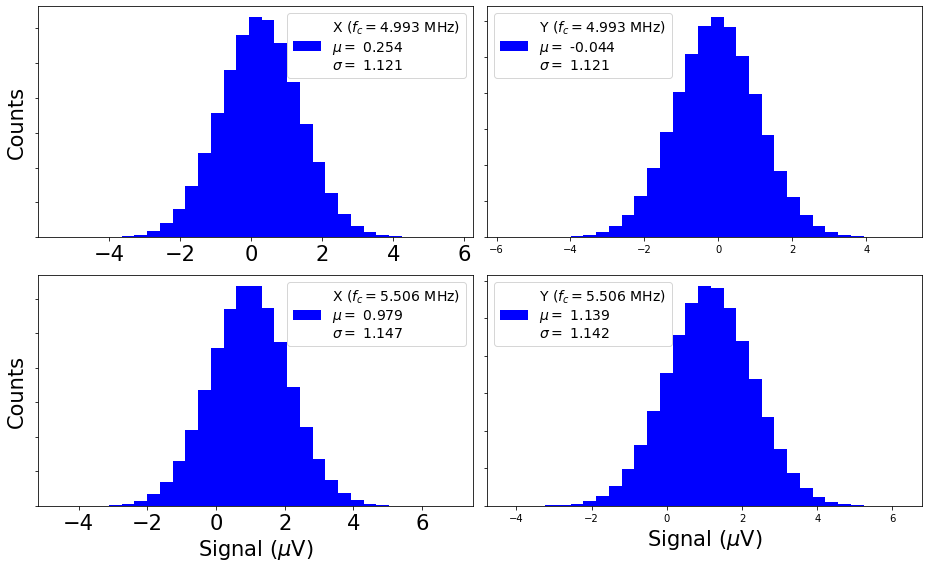

In [38]:
fig, axes = plt.subplots(2,2, figsize=(13,8))
axes[0,0].hist(channel_1X, bins=int((len(channel_1X))** (1 / 4.0)), color='blue', label=r"X ($f_c = $" + str(round(f_lockin1/1e6, 3)) + " MHz)" +'\n'+'$\mu =$ ' + str(format(mean_1X,"1.3f")) + '\n' +'$\sigma =$ ' +str(format(std_1X,"1.3f")));
axes[0,1].hist(channel_1Y, bins=int((len(channel_1Y))** (1 / 4.0)), color='blue', label=r"Y ($f_c = $" + str(round(f_lockin1/1e6, 3)) + " MHz)" +'\n'+'$\mu =$ ' + str(format(mean_1Y,"1.3f")) + '\n' +'$\sigma =$ ' +str(format(std_1Y,"1.3f")));
axes[1,0].hist(channel_2X, bins=int((len(channel_2X))** (1 / 4.0)), color='blue', label=r"X ($f_c = $" + str(round(f_lockin2/1e6, 3)) + " MHz)" +'\n'+'$\mu =$ ' + str(format(mean_2X,"1.3f")) + '\n' +'$\sigma =$ ' +str(format(std_2X,"1.3f")));
axes[1,1].hist(channel_2Y, bins=int((len(channel_2Y))** (1 / 4.0)), color='blue', label=r"Y ($f_c = $" + str(round(f_lockin2/1e6, 3)) + " MHz)" +'\n'+'$\mu =$ ' + str(format(mean_2Y,"1.3f")) + '\n' +'$\sigma =$ ' +str(format(std_2Y,"1.3f")));


axes[0,0].legend(loc=0,fontsize=14)
axes[0,1].legend(loc=0,fontsize=14)
axes[1,0].legend(loc=0,fontsize=14)
axes[1,1].legend(loc=0,fontsize=14)

#axes.grid(True)
#axes.grid(True)
#plt.yticks([])
axes[0,0].yaxis.set_major_formatter(plt.NullFormatter())
axes[0,1].yaxis.set_major_formatter(plt.NullFormatter())
axes[1,0].yaxis.set_major_formatter(plt.NullFormatter())
axes[1,1].yaxis.set_major_formatter(plt.NullFormatter())

#plt.xlim(f_welch1[2], f_welch1[-1])
#plt.ylim(-20,-5)
axes[1,1].set_xlabel(r'Signal ($\mu$V)', fontsize=21)
axes[1,0].set_xlabel(r'Signal ($\mu$V)', fontsize=21)
axes[0,0].set_ylabel(r'Counts', fontsize=21)
axes[1,0].set_ylabel(r'Counts', fontsize=21)


plt.setp(axes[0,0].get_xticklabels(), rotation='horizontal', fontsize=21)
plt.setp(axes[0,1].get_yticklabels(), rotation='horizontal', fontsize=21)
plt.setp(axes[1,0].get_xticklabels(), rotation='horizontal', fontsize=21)
plt.setp(axes[1,1].get_yticklabels(), rotation='horizontal', fontsize=21)

fig.tight_layout()

In [39]:
#magnitude channels

R1 = np.sqrt(channel_1X**2 + channel_1Y**2)
R2 = np.sqrt(channel_2X**2 + channel_2Y**2)

mean_R1 = np.mean(R1)
mean_R2 = np.mean(R2)

std_R1 = np.std(R1)
std_R2 = np.std(R2)

Search for outliers in  all channels

In [40]:
def is_event(data, det_level):
    if data >= det_level:
        return data
    
is_event_list = np.array(list(map(lambda ii : is_event(ii,5*std_R1), R1[:])))
event_times_R1 = [i for i,j in enumerate(is_event_list) if j != None]
print("Detected " + str(len(event_times_R1))+" events in Channel 1")

is_event_list = np.array(list(map(lambda ii : is_event(ii,5*std_R2), R2[:])))
event_times_R2 = [i for i,j in enumerate(is_event_list) if j != None]
print("Detected " + str(len(event_times_R2))+" events in Channel 2")

is_event_list = np.array(list(map(lambda ii : is_event(ii,5*std_1X), channel_1X[:])))
event_times_1X = [i for i,j in enumerate(is_event_list) if j != None]
print("Detected " + str(len(event_times_1X))+" events in Channel 1X")

is_event_list = np.array(list(map(lambda ii : is_event(ii,5*std_1Y), channel_1Y[:])))
event_times_1Y = [i for i,j in enumerate(is_event_list) if j != None]
print("Detected " + str(len(event_times_1Y))+" events in Channel 1Y")

is_event_list = np.array(list(map(lambda ii : is_event(ii,5*std_2X), channel_2X[:])))
event_times_2X = [i for i,j in enumerate(is_event_list) if j != None]
print("Detected " + str(len(event_times_2X))+" events in Channel 2X")

is_event_list = np.array(list(map(lambda ii : is_event(ii,5*std_2Y), channel_2Y[:])))
event_times_2Y = [i for i,j in enumerate(is_event_list) if j != None]
print("Detected " + str(len(event_times_2Y))+" events in Channel 2Y")



Detected 4716 events in Channel 1
Detected 4450 events in Channel 2
Detected 1 events in Channel 1X
Detected 0 events in Channel 1Y
Detected 21 events in Channel 2X
Detected 29 events in Channel 2Y


# Filtered Search

This is an attempt to run a similar search on the data after applying a weiner filter

(This is most likely not correct and was done hastily at the time) The following is what I had written down:

Implimenting an adaptive weiner-kolmogorov filter.

$$W_w(j\omega) = \frac{S_{nu}(\omega)}{S_{nn}(\omega)}$$


Then we divide data into partitions and estimate the noise spectrum $N(\omega)$ for each partition. Adaptive WK filter uses the detector noise spectrum to filter out non-gaussian related noise sources.

From knowledge of the detector determine the systems response $s(t)$ and corresponding fourier transform $S(j\omega)$ to a signal of given shape.

Filter data with the matched adaptive WK filter function 
$$ W_m(j\omega)=S_u\frac{S^*(j\omega)}{N(\omega)}=K\frac{S^*(j\omega)}{N(\omega)}$$

where $Su$ is the broadband amplifier noise, this can be calibrated by applying the known signal (without noise) to the WK filter and adjusting the variable K until the filtered signal is of the same amplitude

In [4]:
#lock-in reference frequencies
f_lockin_run0_5C = 8.392106E+6 + 1.9
f_lockin_run0_3B = 5.505658500E+6 - 2.8
f_lockin_run4_3C = 4.993017E+6 
f_lockin_run4_3B = 5.5056586E+6

#mode frequencies
w_run0_5C = f_lockin_run0_5C*np.pi*2
w_run0_3B = f_lockin_run0_3B*np.pi*2
w_run4_3C = f_lockin_run4_3C*np.pi*2
w_run4_3B = f_lockin_run4_3B*np.pi*2
#electromechanical coupling parameters
kappa_3C = 0.00164284
kappa_3B = 0.00155445
kappa_5C = 0.00106269

#motional resistances of modes
R_3C = 3.0
R_3B = 2.9

#Squid transimpedance (calculated from MMCA Notebook)
Zsquid_5C = 257604
Zsquid_3B = 363360
Zsquid_3C = 396523.297
Zsquid_run0_3B = 363360
# Q factors from Nyquist limit paper
Q_5C = 10.7E7
Q_3B = 1.5E7
Q_3C = 3.7E7
# Measured Q factors
Q_3B = 4.2E7
Q_3C = 4.2E7

tau0_5C = Q_5C/w_run0_5C
tau0_3B = Q_3B/w_run0_3B
tau0_3C = Q_3C/w_run4_3C
#time step
dt=0.01

#reference signal RMS voltage
Vr = 600.0E-3/(np.sqrt(2)*2)

#crystal thickness
h0=0.0005
#crystal phonon trapping parameter
trap=0.848
H0=2.2*10**(-18)

#boltzmans constant
kb = 1.38064852E-23
#electron volt
eV = 1.60218e-19

In [24]:

#location of large impulse signal in data
nn_2 = 13483371

data = f['2X/Data'][nn_2-100000:100000+nn_2]
data-=np.mean(data)

M = data.shape[0]
tn = dt*np.linspace(0,N,N)

#data = f['2X/Data'][:494000000]

In [7]:
#estimation of noise spectrum
fn, Nw = signal.welch(channel_2X[:-M], fs = 1/dt, nperseg = M//64, nfft=2*M-1, scaling='spectrum', return_onesided= True)

In [8]:
channel_2X[:-N]

array([-0.59829295,  1.07380705,  1.53727655, ...,  0.15041335,
        0.07886243, -0.45196809])

In [10]:
#expected signal at output fourier transform
u = 1*np.exp(-tn/2.8)*np.cos(2*np.pi*fr*tn)

In [11]:
#transfer functions of mechanical oscillator and lockin as seen through lock-in

beta1 = 1/1.4
beta2 = 1/0.003

W1 = beta1/(beta1+1j*2*np.pi*(fn-fr))
W2 = beta1/(beta2+1j*2*np.pi*(fn-fr))

In [12]:
#weiner filter transfer functions
K=(4j)
Ww = K*np.conj(W1)*np.conj(W2)/Nw

Text(0, 0.5, '$|W_w~(\\omega)|$')

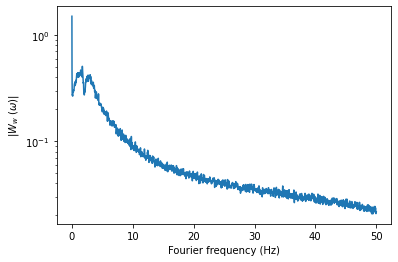

In [13]:
fig,ax = plt.subplots(1)
ax.semilogy(fn,np.abs(Ww))
ax.set_xlabel(r'Fourier frequency (Hz)')
ax.set_ylabel(r'$|W_w~(\omega)|$')


In [16]:
#automatic calibration 
K=1j
Ww = K*np.conj(W1)*np.conj(W2)/Nw

sig_fft = fft.fft(u)
sig_filt = np.real(fft.ifft(sig_fft*Ww))

#determining phase difference from signal correlation
xcorr = signal.correlate(sig_filt,u)
tncorr=dt*np.linspace(-M,M,2*M-1)
tdiff = tncorr[xcorr.argmax()]

#signal amplitude
filt_amp = np.min(sig_filt)
sig_amp = np.min(u)


while filt_amp > sig_amp:
    K += 1j
    Ww = K*np.conj(W1)*np.conj(W2)/Nw

    sig_fft = fft.fft(u)
    sig_filt = np.real(fft.ifft(sig_fft*Ww))
    filt_amp = np.min(sig_filt)
    sig_amp = np.min(u)
    
    

Text(0, 0.5, 'Signal ($\\mu V$)')

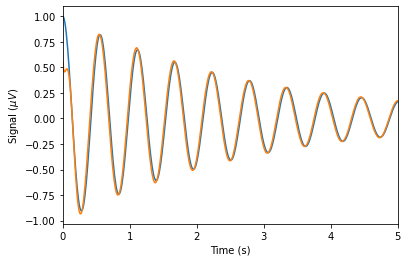

In [17]:
#calibrate the filter by filtering signal (no noise) of known amplitude -> filtered signal should be of same aplitude

sig_fft = fft.fft(u)
sig_filt = np.real(fft.ifft(sig_fft*Ww))


fig,ax = plt.subplots(1)
ax.plot(tn,u)
ax.plot(tn,sig_filt)
ax.set_xlim(0,5)
ax.set_xlabel(r'Time (s)')
ax.set_ylabel(r'Signal ($\mu V$)')

In [26]:
data_fft = fft.fft(data)
data_filt = np.real(fft.ifft(data_fft*Ww))

(810.0, 830.0)

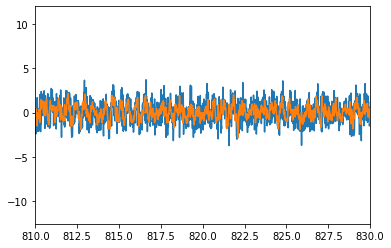

In [30]:
fig, ax = plt.subplots(1)
ax.plot(tn,data)
ax.plot(tn,data_filt)
ax
ax.set_xlim(810,830)